# Exploración de cobertura, segmentación y supuestos de la política de labels

**Etapa 03 — análisis de sensibilidad, sin cambios sobre el pipeline**

Este notebook audita la política `report-label-policy-v1.0.0` y evalúa alternativas en orden creciente de severidad del supuesto. No modifica módulos, configuración ni artefactos de supervisión. Todo resultado alternativo es contrafactual y se mantiene dentro del notebook.

Preguntas de trabajo:

1. ¿La proporción de pares resueltos y no resueltos sugiere brechas léxicas específicas por idioma y target?
2. ¿Qué vocabulario aparece en cláusulas diagnósticas que ninguna regla puede etiquetar?
3. ¿Qué longitudes y boundaries producen fragmentos potencialmente informativos pero no clasificables?
4. ¿Qué costo observable tendría cambiar `no mention → unknown` por `no mention → negative` con baja confianza?

> **Criterio de lectura.** Las agrupaciones de idioma son heurísticas reproducibles del pipeline, no identificaciones lingüísticas validadas. Los 58 estudios con labels oficiales constituyen un conjunto pequeño; las estimaciones por idioma o target deben interpretarse como señales de riesgo, no como tasas poblacionales estables.

## 0. Preparación y contrato del análisis

Se reutilizan exclusivamente `train.csv`, los artefactos versionados de la etapa 03 y las funciones existentes de normalización/segmentación. El código auxiliar se limita a construir tablas de auditoría y escenarios contrafactuales.

In [1]:
from pathlib import Path
from collections import Counter
import json, math, re, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'data' / 'train.csv').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from report_labels.constants import (
    ANATOMY_TERMS, DIRECT_TERMS, NEGATION_TERMS, NORMALITY_TERMS,
    OA_TERMS, PATHOLOGY_TERMS, TARGETS, UNCERTAINTY_TERMS,
)
from report_labels.extraction import ReportLabelExtractor
from report_labels.text import contains_any, normalize_text, segment_report

pd.set_option('display.max_colwidth', 150)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'resolved': '#2f6f8f', 'unresolved': '#c7c7c7', 'risk': '#b64a4a'}
extractor = ReportLabelExtractor()

In [2]:
train = pd.read_csv(ROOT / 'data' / 'train.csv', dtype={'StudyInstanceUID': str})
supervision = pd.read_csv(
    ROOT / 'artifacts' / '03_report_label_generation' / 'supervision_long_v1.csv',
    dtype={'StudyInstanceUID': str},
)
gold = supervision.loc[supervision['official_label'].notna()].copy()

assert len(train) == train['StudyInstanceUID'].nunique() == 4407
assert len(supervision) == len(train) * len(TARGETS)
assert gold['StudyInstanceUID'].nunique() == 58

display(pd.DataFrame({
    'unidad': ['estudios', 'pares estudio-target', 'estudios gold', 'targets'],
    'n': [len(train), len(supervision), gold['StudyInstanceUID'].nunique(), len(TARGETS)],
}))

,unidad,n
0,estudios,4407
1,pares estudio-target,52884
2,estudios gold,58
3,targets,12


## 1. Severidad baja: cobertura por idioma y target

Primero se mide el comportamiento vigente sin introducir vocabulario nuevo. Un par se considera **resuelto** únicamente si su estado derived es `positive` o `negative`; `unknown` y `uncertain` permanecen no resueltos.

,studies,pairs,resolved,unresolved,resolved_rate,unresolved_share
language_group,,,,,,
cyrillic_script,220,2640,253,2387,9.6%,6.4%
greek_script,321,3852,441,3411,11.4%,9.2%
south_slavic,321,3852,496,3356,12.9%,9.1%
german,255,3060,416,2644,13.6%,7.1%
spanish,678,8136,1439,6697,17.7%,18.1%
dutch,153,1836,328,1508,17.9%,4.1%
latin_other,368,4416,871,3545,19.7%,9.6%
turkish,546,6552,1411,5141,21.5%,13.9%
french,80,960,370,590,38.5%,1.6%


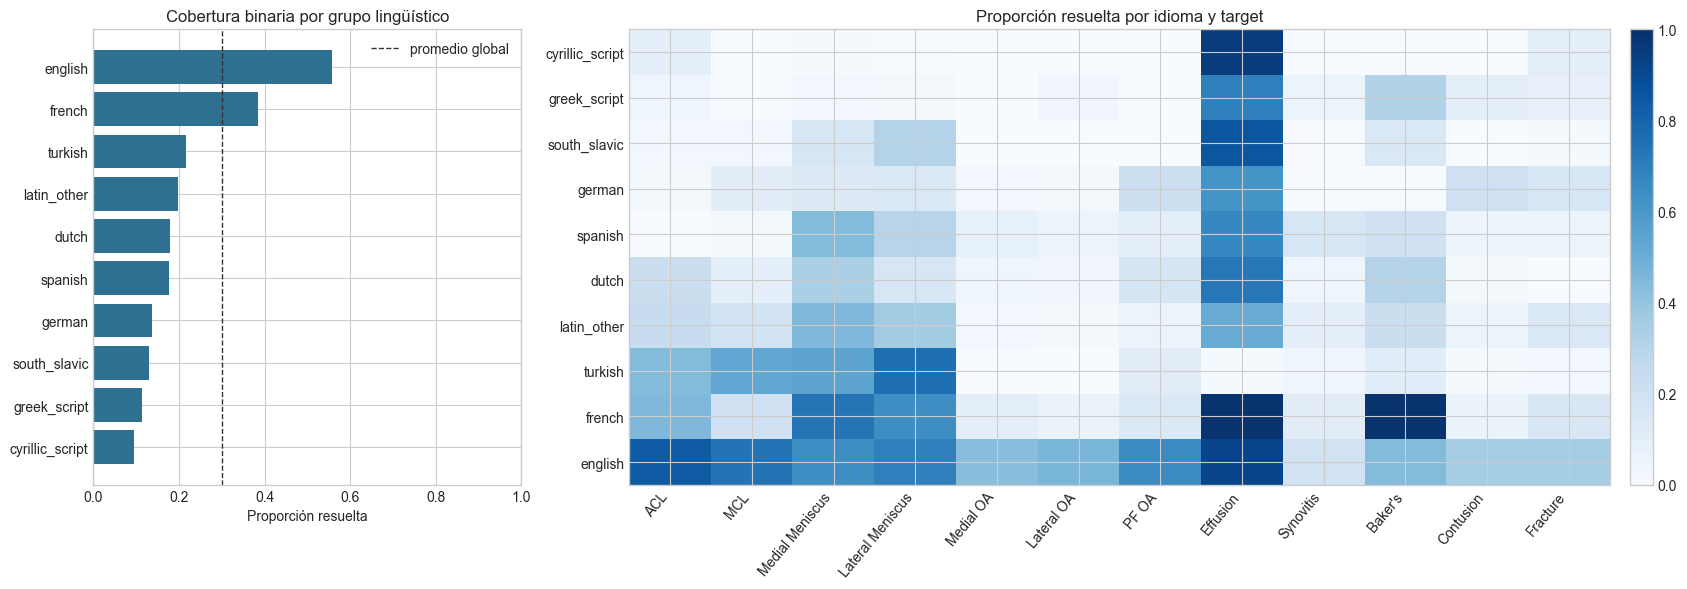

In [3]:
supervision['resolved'] = supervision['status'].isin(['positive', 'negative'])
language_summary = (
    supervision.groupby('language_group', observed=True)
    .agg(pairs=('resolved', 'size'), resolved=('resolved', 'sum'))
    .assign(
        unresolved=lambda x: x['pairs'] - x['resolved'],
        resolved_rate=lambda x: x['resolved'] / x['pairs'],
        unresolved_share=lambda x: (x['pairs'] - x['resolved']) / (~supervision['resolved']).sum(),
    )
)
studies_by_language = supervision.groupby('language_group')['StudyInstanceUID'].nunique()
language_summary.insert(0, 'studies', studies_by_language)
display(language_summary.sort_values('resolved_rate').style.format({
    'resolved_rate': '{:.1%}', 'unresolved_share': '{:.1%}'
}))

language_target = (
    supervision.pivot_table(index='language_group', columns='target', values='resolved', aggfunc='mean')
    .reindex(columns=TARGETS)
)
fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [1, 2.4]})
ordered = language_summary.sort_values('resolved_rate')
axes[0].barh(ordered.index, ordered['resolved_rate'], color=COLORS['resolved'])
axes[0].axvline(supervision['resolved'].mean(), color='#333333', ls='--', lw=1, label='promedio global')
axes[0].set(xlabel='Proporción resuelta', title='Cobertura binaria por grupo lingüístico', xlim=(0, 1))
axes[0].legend(frameon=False)
im = axes[1].imshow(language_target.loc[ordered.index], aspect='auto', vmin=0, vmax=1, cmap='Blues')
axes[1].set_xticks(range(len(TARGETS)), TARGETS, rotation=50, ha='right')
axes[1].set_yticks(range(len(ordered)), ordered.index)
axes[1].set_title('Proporción resuelta por idioma y target')
fig.colorbar(im, ax=axes[1], fraction=0.025, pad=0.02)
fig.tight_layout()
plt.show()

In [4]:
lowest = language_summary['resolved_rate'].idxmin()
highest = language_summary['resolved_rate'].idxmax()
ratio = language_summary.loc[highest, 'resolved_rate'] / language_summary.loc[lowest, 'resolved_rate']
display(Markdown(
    f"**Interpretación.** La cobertura varía desde **{language_summary.loc[lowest, 'resolved_rate']:.1%}** "
    f"en `{lowest}` hasta **{language_summary.loc[highest, 'resolved_rate']:.1%}** en `{highest}` "
    f"(razón {ratio:.1f}×). Esta heterogeneidad no prueba por sí sola que falten términos: también puede "
    "reflejar estilos de reporte, longitud, secciones o errores del agrupador lingüístico. Sí demuestra que el "
    "estado `unknown` no es intercambiable entre idiomas. **Implicancia:** cualquier ampliación del léxico y "
    "cualquier imputación de silencios debe evaluarse estratificada por idioma y target; una métrica global ocultaría "
    "los grupos con mayor exposición a pseudo-labels."
))

**Interpretación.** La cobertura varía desde **9.6%** en `cyrillic_script` hasta **55.9%** en `english` (razón 5.8×). Esta heterogeneidad no prueba por sí sola que falten términos: también puede reflejar estilos de reporte, longitud, secciones o errores del agrupador lingüístico. Sí demuestra que el estado `unknown` no es intercambiable entre idiomas. **Implicancia:** cualquier ampliación del léxico y cualquier imputación de silencios debe evaluarse estratificada por idioma y target; una métrica global ocultaría los grupos con mayor exposición a pseudo-labels.

## 2. Severidad baja–media: cláusulas imposibles de etiquetar y candidatos léxicos

Definición operacional: una cláusula diagnóstica es **no resoluble por las reglas actuales** cuando no aparece como evidencia de ningún target en el artefacto derived. Esta definición es deliberadamente estricta a nivel de cláusula: no afirma que el texto contenga un hallazgo verdadero, sólo que ninguna regla produjo un estado binario o incierto a partir de él.

Se marca como **potencialmente informativa** si, además, contiene al menos un ancla anatómica/target o vocabulario de patología, normalidad, negación o incertidumbre. Es una cola de auditoría, no una lista automática de términos a incorporar.

In [5]:
language_by_uid = (
    supervision[['StudyInstanceUID', 'language_group']].drop_duplicates()
    .set_index('StudyInstanceUID')['language_group'].to_dict()
)
evidence_by_uid = {}
for uid, values in supervision.groupby('StudyInstanceUID')['evidence']:
    evidence_by_uid[uid] = {text[:500] for raw in values for text in json.loads(raw) if text}

def target_hits(text):
    return tuple(target for target in TARGETS if contains_any(text, ANATOMY_TERMS.get(target, DIRECT_TERMS.get(target, ()))))

all_finding_terms = tuple(dict.fromkeys((*PATHOLOGY_TERMS, *OA_TERMS)))
all_modifier_terms = tuple(dict.fromkeys((*NEGATION_TERMS, *NORMALITY_TERMS, *UNCERTAINTY_TERMS)))
clause_rows = []
for record in train[['StudyInstanceUID', 'Report']].itertuples(index=False):
    clauses = segment_report(record.Report)
    for index, clause in enumerate(clauses):
        hits = target_hits(clause.text)
        words = re.findall(r'[^\W\d_]+', clause.text, flags=re.UNICODE)
        is_evidence = clause.text[:500] in evidence_by_uid[record.StudyInstanceUID]
        has_finding = contains_any(clause.text, all_finding_terms)
        has_modifier = contains_any(clause.text, all_modifier_terms)
        clause_rows.append({
            'StudyInstanceUID': record.StudyInstanceUID, 'language_group': language_by_uid[record.StudyInstanceUID],
            'clause_index': index, 'section': clause.section, 'diagnostic': clause.diagnostic,
            'text': clause.text, 'chars': len(clause.text), 'words': len(words),
            'target_hits': hits, 'n_target_hits': len(hits), 'has_finding': has_finding,
            'has_modifier': has_modifier, 'rule_resolved': is_evidence,
        })
clauses = pd.DataFrame(clause_rows)
clauses['impossible'] = clauses['diagnostic'] & ~clauses['rule_resolved']
clauses['informative_impossible'] = (
    clauses['impossible'] & (clauses['n_target_hits'].gt(0) | clauses['has_finding'] | clauses['has_modifier'])
    & clauses['words'].ge(3)
)
display(pd.Series({
    'cláusulas totales': len(clauses),
    'cláusulas diagnósticas': int(clauses['diagnostic'].sum()),
    'usadas como evidencia': int(clauses['rule_resolved'].sum()),
    'diagnósticas no resolubles': int(clauses['impossible'].sum()),
    'no resolubles potencialmente informativas': int(clauses['informative_impossible'].sum()),
}).to_frame('n'))

,n
cláusulas totales,81647
cláusulas diagnósticas,76909
usadas como evidencia,18893
diagnósticas no resolubles,58134
no resolubles potencialmente informativas,25737


,clauses,chars_median,chars_p90,words_median,words_p90,pct_short_2w
audit_class,,,,,,
evidencia actual,18775,60.000000,125.000000,8.000000,18.000000,2.8%
no resoluble informativa,25737,50.000000,105.000000,6.000000,15.000000,0.0%
no resoluble restante,32397,43.000000,98.000000,6.000000,14.000000,26.4%


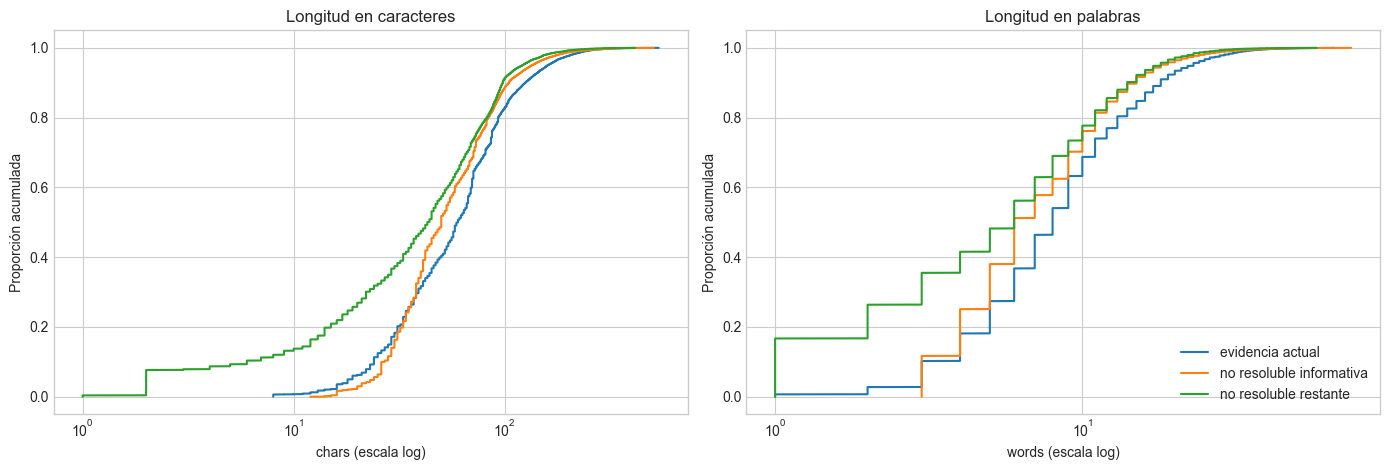

In [6]:
clauses['audit_class'] = np.select(
    [clauses['rule_resolved'], clauses['informative_impossible']],
    ['evidencia actual', 'no resoluble informativa'],
    default='no resoluble restante',
)
length_summary = (
    clauses.loc[clauses['diagnostic']].groupby('audit_class', observed=True)
    .agg(
        clauses=('text', 'size'),
        chars_median=('chars', 'median'), chars_p90=('chars', lambda x: x.quantile(.90)),
        words_median=('words', 'median'), words_p90=('words', lambda x: x.quantile(.90)),
        pct_short_2w=('words', lambda x: x.le(2).mean()),
    )
)
display(length_summary.style.format({'pct_short_2w': '{:.1%}'}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for label, frame in clauses.loc[clauses['diagnostic']].groupby('audit_class', observed=True):
    for ax, column in zip(axes, ['chars', 'words']):
        values = np.sort(frame[column].clip(lower=1))
        ax.plot(values, np.arange(1, len(values) + 1) / len(values), label=label)
        ax.set_xscale('log')
        ax.set_xlabel(f'{column} (escala log)')
        ax.set_ylabel('Proporción acumulada')
axes[0].set_title('Longitud en caracteres')
axes[1].set_title('Longitud en palabras')
axes[1].legend(frameon=False, loc='lower right')
fig.tight_layout()
plt.show()

In [7]:
STOPWORDS = set(
    'that this with from were was are and the for not without have has into over under there their ' 
    'para por con sin una uno los las del que como esta este se no hay son ' 
    'dans avec sans une des les est sont pas pour sur ' 
    'geen niet een van het met voor zijn ' 
    'keine nicht ohne eine der die das mit und ist sind ' 
    'icin ile bir yok diz mevcut olarak ' 
    'nema nije bez uredan vidi koljena koljenu'.split()
)
known_tokens = set(re.findall(
    r'[^\W\d_]{4,}',
    ' '.join(term for terms in [*ANATOMY_TERMS.values(), *DIRECT_TERMS.values(), NEGATION_TERMS,
                                NORMALITY_TERMS, UNCERTAINTY_TERMS, PATHOLOGY_TERMS, OA_TERMS] for term in terms),
    flags=re.UNICODE,
))

def clause_document_frequency(texts):
    counter = Counter()
    for text in texts:
        tokens = {token for token in re.findall(r'[^\W\d_]{4,}', text, flags=re.UNICODE)
                  if token not in STOPWORDS and token not in known_tokens}
        counter.update(tokens)
    return counter

candidate_rows = []
for language, frame in clauses.loc[clauses['diagnostic']].groupby('language_group', observed=True):
    unresolved_texts = frame.loc[frame['informative_impossible'], 'text']
    resolved_texts = frame.loc[frame['rule_resolved'], 'text']
    u, r = clause_document_frequency(unresolved_texts), clause_document_frequency(resolved_texts)
    nu, nr = max(1, len(unresolved_texts)), max(1, len(resolved_texts))
    for token, count in u.items():
        if count < 4:
            continue
        lift = math.log2(((count + 1) / (nu + 2)) / ((r[token] + 1) / (nr + 2)))
        candidate_rows.append((language, token, count, r[token], lift, lift * math.log1p(count)))
lexical_candidates = pd.DataFrame(
    candidate_rows, columns=['language_group', 'token', 'impossible_clause_df', 'evidence_clause_df', 'log2_lift', 'rank_score']
)
lexical_candidates['rank'] = lexical_candidates.groupby('language_group')['rank_score'].rank(method='first', ascending=False)
display(
    lexical_candidates.loc[lexical_candidates['rank'].le(8)]
    .sort_values(['language_group', 'rank'])
    .drop(columns=['rank_score'])
    .style.format({'log2_lift': '{:.2f}', 'rank': '{:.0f}'})
)

,language_group,token,impossible_clause_df,evidence_clause_df,log2_lift,rank
13,cyrillic_script,особености,117,0,6.52,1
16,cyrillic_script,хрущял,91,2,4.57,2
14,cyrillic_script,феморис,38,0,4.92,3
15,cyrillic_script,квадрицепс,38,0,4.92,4
23,cyrillic_script,ставният,38,0,4.92,5
24,cyrillic_script,лигаменти,38,0,4.92,6
25,cyrillic_script,колатерални,36,0,4.84,7
5,cyrillic_script,задния,31,0,4.63,8
122,dutch,intacte,92,0,5.79,1
130,dutch,collateraal,86,1,4.70,2


### Control con misses positivos del gold set

Los tokens anteriores pueden ser frecuentes por estilo y no por semántica clínica. Para aumentar la prioridad se cruzan con pares oficialmente positivos que el extractor dejó `unknown` o `uncertain`. Las cláusulas mostradas son sólo excerpts candidatos; el label oficial es a nivel de reporte-target y no localiza la evidencia textual.

In [8]:
gold_positive_misses = gold.loc[
    gold['official_label'].eq(1) & gold['status'].isin(['unknown', 'uncertain']),
    ['StudyInstanceUID', 'target', 'status', 'language_group'],
].copy()
miss_counts = gold_positive_misses.groupby(['language_group', 'target']).size().unstack(fill_value=0).reindex(columns=TARGETS, fill_value=0)
display(miss_counts.loc[miss_counts.sum(axis=1).gt(0)].assign(total=lambda x: x.sum(axis=1)))

excerpt_rows = []
for miss in gold_positive_misses.itertuples(index=False):
    pool = clauses.loc[
        clauses['StudyInstanceUID'].eq(miss.StudyInstanceUID) & clauses['impossible']
    ].copy()
    if pool.empty:
        continue
    pool['target_priority'] = pool['target_hits'].map(lambda hits: miss.target in hits)
    pool = pool.sort_values(['target_priority', 'informative_impossible', 'words'], ascending=False)
    best = pool.iloc[0]
    excerpt_rows.append({
        'uid_suffix': miss.StudyInstanceUID[-14:], 'language_group': miss.language_group,
        'target': miss.target, 'derived_status': miss.status,
        'target_anchor_in_excerpt': bool(best['target_priority']), 'excerpt': best['text'][:320],
    })
display(pd.DataFrame(excerpt_rows).head(25))

target,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture,total
language_group,,,,,,,,,,,,,
cyrillic_script,1,0,1,0,0,0,1,0,1,1,2,0,7
dutch,0,1,1,2,1,1,1,0,1,0,0,0,8
english,0,1,1,2,0,2,3,1,3,1,3,1,18
german,1,0,0,0,0,0,1,0,2,1,0,1,6
greek_script,1,1,2,2,2,0,1,1,3,0,2,1,16
latin_other,0,0,1,0,3,2,2,1,3,1,1,0,14
south_slavic,1,0,2,1,2,1,2,0,1,0,1,1,12
spanish,2,1,0,2,1,1,6,0,1,0,0,1,15
turkish,3,0,2,1,1,0,1,5,2,0,2,2,19


,uid_suffix,language_group,target,derived_status,target_anchor_in_excerpt,excerpt
0,38520594649149,spanish,PF OA,unknown,False,condropatia focal grado 4 del aspecto inferior de la vertiente medial de la troclea femoral .
1,05248839028269,english,PF OA,unknown,False,"the fcl, popliteus and biceps femoris tendons are preserved."
2,88080836752052,english,Medial Meniscus,unknown,True,"medial compartment: medial meniscus: extensive complete tearing of the body, posterior horn, and posterior root medial meniscus with severe extrus..."
3,88080836752052,english,Synovitis,unknown,False,"medial compartment: medial meniscus: extensive complete tearing of the body, posterior horn, and posterior root medial meniscus with severe extrus..."
4,40089882701935,english,Synovitis,unknown,False,"the patellofemoral joint, the patellar and trochlear cartilage appears congruent without chondral lesion."
5,27959098335840,spanish,ACL,unknown,False,hallazgos: rotura espesor y ancho total de la union del tercio medio del tercio proximal del lca asociado a
6,73408583976756,english,MCL,uncertain,False,> the quadriceps and patellar tendons appear to be within normal.
7,73408583976756,english,Contusion,uncertain,False,> the quadriceps and patellar tendons appear to be within normal.
8,09606907169581,english,Lateral OA,unknown,False,"anterior compartment (extensor mechanism, cartilage, hoffa's fat pad): multifocal deep and delaminating fissuring of the articular cartilage of th..."
9,09606907169581,english,PF OA,unknown,True,"conclusion: tricompartmental moderate chondral thinning with deep fissures at the lateral and patellofemoral compartments, as described above."


In [9]:
multi_item_impossible = (
    clauses.loc[clauses['informative_impossible'] & (clauses['n_target_hits'].ge(2) | (clauses['has_finding'] & clauses['has_modifier']))]
    .sort_values(['n_target_hits', 'words'], ascending=False)
    [['language_group', 'n_target_hits', 'target_hits', 'has_finding', 'has_modifier', 'words', 'text']]
)
display(multi_item_impossible.head(25))
display(Markdown(
    f"**Interpretación.** Se identificaron **{clauses['informative_impossible'].sum():,}** cláusulas diagnósticas "
    "no resolubles que aún contienen señales compatibles con contenido clínico. Los términos con alto `log2_lift` "
    "son candidatos para revisión bilingüe y radiológica; no deben agregarse por frecuencia solamente. Los excerpts del "
    "gold positivo son la cola de mayor valor, pero siguen sin demostrar qué frase sustenta el label oficial. "
    "**Implicancia:** la modificación de menor riesgo es ampliar tests y léxico sólo para expresiones validadas en "
    "contexto, target e idioma, midiendo simultáneamente cobertura y falsos positivos."
))

,language_group,n_target_hits,target_hits,has_finding,has_modifier,words,text
1406,french,3,"(ACL, Medial Meniscus, Lateral Meniscus)",False,True,48,"autrement le ligament croise anterieur, le ligament croise posterieur, le menisque interne, le menisque externe, le mecanisme des extenseurs, le l..."
5586,french,3,"(ACL, Medial Meniscus, Lateral Meniscus)",False,True,48,"autrement, le ligament croise anterieur, le ligament croise posterieur, le menisque interne, le menisque externe, le mecanisme des extenseurs, le ..."
50895,french,3,"(ACL, Medial Meniscus, Lateral Meniscus)",False,True,48,"autrement, le ligament croise anterieur, le ligament croise posterieur, le menisque interne, le menisque externe, le mecanisme des extenseurs, le ..."
51785,french,3,"(ACL, Medial Meniscus, Lateral Meniscus)",False,True,48,"autrement, le ligament croise anterieur, le ligament croise posterieur, le mecanisme des extenseurs, le menisque interne, le menisque externe, le ..."
59784,english,3,"(Medial OA, Lateral OA, PF OA)",True,False,19,there are mild degenerative changes involving the patellofemoral and lateral compartment with moderate degenerative changes in the medial compartm...
49073,french,3,"(Medial OA, Lateral OA, PF OA)",False,False,15,"changements degeneratifs : chondropatie legere a moderee du compartiment medial, legere du compartiment lateral et femoropatellaire."
65249,english,2,"(Medial Meniscus, Medial OA)",False,False,57,medial compartment: medial meniscus: abnormal linear hyperintense signal in the body and posterior horn of the meniscus extending obliquely to the...
45412,french,2,"(Medial Meniscus, Lateral Meniscus)",False,True,45,"autrement, le cartilage articulaire, le signal de la moelle osseuse, le menisque interne, le menisque externe, le mecanisme des extenseurs, le sem..."
60282,french,2,"(Medial Meniscus, Lateral Meniscus)",False,True,40,"autrement, le menisque interne, le menisque externe, le mecanisme des extenseurs, le ligament collateral interne, le semi-membraneux, le muscle et..."
10259,english,2,"(Medial Meniscus, Medial OA)",False,False,39,medial compartment: medial meniscus: complex medial meniscal tears including truncation at the inner margin of the posterior horn with horizontal ...


**Interpretación.** Se identificaron **25,737** cláusulas diagnósticas no resolubles que aún contienen señales compatibles con contenido clínico. Los términos con alto `log2_lift` son candidatos para revisión bilingüe y radiológica; no deben agregarse por frecuencia solamente. Los excerpts del gold positivo son la cola de mayor valor, pero siguen sin demostrar qué frase sustenta el label oficial. **Implicancia:** la modificación de menor riesgo es ampliar tests y léxico sólo para expresiones validadas en contexto, target e idioma, midiendo simultáneamente cobertura y falsos positivos.

## 3. Severidad media: stress test de boundaries

La regla vigente separa después de `.`, `!`, `?`, `;` y en saltos de línea; además une un fragmento terminado en `:` con el siguiente. Para detectar pérdida potencial de alcance se comparan pares adyacentes con señales clínicas bajo dos lecturas:

- **actual:** se conserva el boundary;
- **joined:** el boundary se reemplaza por una coma y se vuelve a ejecutar el extractor.

Una diferencia es una **sensibilidad al boundary**, no evidencia de que unir sea correcto. De hecho, unir puede extender indebidamente una negación o una incertidumbre. El objetivo es producir casos para inspección y tests de regresión.

In [10]:
def extraction_signature(text):
    return {target: result.status for target, result in extractor.extract(text).items() if result.status != 'unknown'}

boundary_candidates = []
for uid, frame in clauses.sort_values('clause_index').groupby('StudyInstanceUID', sort=False):
    records = list(frame.itertuples(index=False))
    for left, right in zip(records, records[1:]):
        marker_count = left.n_target_hits + right.n_target_hits + left.has_finding + right.has_finding + left.has_modifier + right.has_modifier
        if marker_count < 2 or not (left.diagnostic or right.diagnostic):
            continue
        ending = left.text.rstrip()[-1:]
        boundary_type = ending if ending in '.!?;' else 'newline'
        actual_text = left.text + ('\n' if boundary_type == 'newline' else ' ') + right.text
        joined_text = left.text.rstrip(' .!?;') + ', ' + right.text
        current, joined = extraction_signature(actual_text), extraction_signature(joined_text)
        changed = sorted(target for target in TARGETS if current.get(target, 'unknown') != joined.get(target, 'unknown'))
        if changed:
            boundary_candidates.append({
                'StudyInstanceUID': uid, 'language_group': left.language_group, 'boundary': boundary_type,
                'changed_targets': tuple(changed), 'n_changed': len(changed),
                'current': current, 'joined': joined,
                'left': left.text[-220:], 'right': right.text[:220],
            })
boundary_risk = pd.DataFrame(boundary_candidates)
if boundary_risk.empty:
    display(Markdown('No se detectaron pares sensibles bajo este stress test.'))
else:
    display(boundary_risk.groupby(['boundary', 'language_group']).size().unstack(fill_value=0))
    display(boundary_risk.sort_values('n_changed', ascending=False).head(25))

language_group,cyrillic_script,dutch,english,french,german,greek_script,latin_other,south_slavic,spanish,turkish
boundary,,,,,,,,,,
.,29,143,3140,170,224,103,272,144,639,678
;,0,0,92,0,0,0,43,1,0,0
?,0,2,0,0,0,0,0,1,0,1
newline,0,0,166,1,0,0,76,38,118,0


,StudyInstanceUID,language_group,boundary,changed_targets,n_changed,current,joined,left,right
1861,1.2.826.0.1.3680043.8.498.87253761427012478584873622994909841751,latin_other,.,"(Effusion, Medial Meniscus, Medial OA, PF OA, Synovitis)",5,"{'Medial Meniscus': 'positive', 'Medial OA': 'positive', 'PF OA': 'positive', 'Effusion': 'positive', 'Synovitis': 'positive'}",{},technique: mri of the knee.,"results: complete tear of the posterior horn of the medial meniscus with subluxation, full-thickness cartilage loss in the medial compartment with..."
1827,1.2.826.0.1.3680043.8.498.20733151481921261415295204209910573639,english,.,"(Lateral Meniscus, Lateral OA, Medial Meniscus)",3,"{'Medial Meniscus': 'positive', 'Lateral Meniscus': 'positive', 'Medial OA': 'negative'}","{'Medial Meniscus': 'negative', 'Lateral Meniscus': 'negative', 'Medial OA': 'negative', 'Lateral OA': 'negative'}",medial compartment cartilage: no focal cartilage defects.,lateral compartment: lateral meniscus: horizontal tear in the posterior body and posterior horn of the medial meniscus.
2382,1.2.826.0.1.3680043.8.498.67678576373934022409084801948795250361,english,.,"(Lateral OA, Medial OA, PF OA)",3,"{'Medial Meniscus': 'uncertain', 'Medial OA': 'positive', 'Lateral OA': 'positive', 'PF OA': 'positive'}","{'Medial Meniscus': 'uncertain', 'Medial OA': 'uncertain', 'Lateral OA': 'uncertain', 'PF OA': 'uncertain'}","tricompartmental osteoarthritis of the left knee by evidence of chondrosis, subchondral edema, cysts and osteophytes.",suspected small horizontal tear at the body of the medial meniscus.
2757,1.2.826.0.1.3680043.8.498.10314240078685804110739316196999571466,english,newline,"(Lateral OA, Medial OA, PF OA)",3,"{'Medial OA': 'positive', 'Lateral OA': 'positive', 'PF OA': 'positive'}","{'Medial OA': 'negative', 'Lateral OA': 'negative', 'PF OA': 'negative'}",other findings: none,"conclusion: tricompartmental chondropathy, severe in the lateral compartment, which have progressed."
1252,1.2.826.0.1.3680043.8.498.47870074144891988520855535250618228390,english,.,"(Lateral OA, Medial OA, PF OA)",3,"{'Medial OA': 'positive', 'Lateral OA': 'positive', 'PF OA': 'positive'}","{'Medial OA': 'negative', 'Lateral OA': 'negative', 'PF OA': 'negative'}",no displaced meniscal flap.,tricompartmental chondropathy as described above.
1953,1.2.826.0.1.3680043.8.498.51426696939581135481763379246368970360,french,.,"(Lateral OA, Medial OA, PF OA)",3,{},"{'Medial OA': 'negative', 'Lateral OA': 'negative', 'PF OA': 'negative'}","changements degeneratifs : chondropatie legere a moderee du compartiment medial, legere du compartiment lateral et femoropatellaire.",signal de la moelle osseuse : normal.
1952,1.2.826.0.1.3680043.8.498.51426696939581135481763379246368970360,french,.,"(Lateral OA, Medial OA, PF OA)",3,{},"{'Medial OA': 'negative', 'Lateral OA': 'negative', 'PF OA': 'negative'}",alignement articulaire : normal.,"changements degeneratifs : chondropatie legere a moderee du compartiment medial, legere du compartiment lateral et femoropatellaire."
835,1.2.826.0.1.3680043.8.498.86029947807373604003071651721618330827,english,.,"(Lateral OA, Medial OA, PF OA)",3,"{'Medial OA': 'positive', 'Lateral OA': 'positive', 'PF OA': 'positive'}","{'Medial OA': 'negative', 'Lateral OA': 'negative', 'PF OA': 'negative'}",no aggressive osseous lesions.,small tricompartmental marginal osteophyte formation.
889,1.2.826.0.1.3680043.8.498.64703506772167798469048460791472465039,english,.,"(ACL, Fracture, Lateral Meniscus)",3,"{'ACL': 'positive', 'Lateral Meniscus': 'positive', 'Fracture': 'positive'}","{'ACL': 'negative', 'Lateral Meniscus': 'negative', 'Fracture': 'negative'}",other significant findings: none.,"conclusion: *comminuted mildly displaced avulsion fracture of the tibial spine with mild comminution, including the distal insertion of the acl, t..."
836,1.2.826.0.1.3680043.8.498.86029947807373604003071651721618330827,english,.,"(Lateral OA, Medial OA, PF OA)",3,"{'Medial OA': 'positive',

In [11]:
short_fragments = clauses.loc[clauses['diagnostic'] & clauses['words'].le(2)]
hard_boundary_risk = boundary_risk.loc[boundary_risk['boundary'].isin([';', 'newline'])] if not boundary_risk.empty else boundary_risk
display(Markdown('**Casos sensibles a separadores típicos de listas (`;` o salto de línea).**'))
display(hard_boundary_risk.sort_values(['n_changed', 'boundary'], ascending=False).head(20))
boundary_n = len(boundary_risk)
hard_boundary_n = len(hard_boundary_risk)
display(Markdown(
    f"**Interpretación.** La segmentación produce **{len(short_fragments):,}** fragmentos diagnósticos de hasta dos "
    f"palabras y el stress test encuentra **{boundary_n:,}** pares cuyo resultado cambia al neutralizar el separador; "
    f"**{hard_boundary_n:,}** involucran `;` o saltos de línea, separadores típicos de listas. "
    "Esto localiza casos donde el alcance de anatomía, negación o hallazgo puede depender del corte. No permite concluir "
    "que deba eliminarse un tipo de boundary de manera global. **Implicancia:** antes de cambiar `_BOUNDARY`, conviene "
    "convertir una muestra estratificada de estos pares —en especial listas de anomalías detectadas/no detectadas— en "
    "tests anotados; luego comparar reglas sensibles a listas o encabezados contra precisión, no sólo cobertura."
))

**Casos sensibles a separadores típicos de listas (`;` o salto de línea).**

,StudyInstanceUID,language_group,boundary,changed_targets,n_changed,current,joined,left,right
2757,1.2.826.0.1.3680043.8.498.10314240078685804110739316196999571466,english,newline,"(Lateral OA, Medial OA, PF OA)",3,"{'Medial OA': 'positive', 'Lateral OA': 'positive', 'PF OA': 'positive'}","{'Medial OA': 'negative', 'Lateral OA': 'negative', 'PF OA': 'negative'}",other findings: none,"conclusion: tricompartmental chondropathy, severe in the lateral compartment, which have progressed."
734,1.2.826.0.1.3680043.8.498.11287937729196958426538087439102017580,english,newline,"(ACL, MCL)",2,"{'ACL': 'negative', 'MCL': 'negative'}","{'ACL': 'uncertain', 'MCL': 'uncertain'}","> there is no increased intensity in the acl, mcl and lcl, it appears to be normal","> interstitial high intensity, irregular contour and laxity in the pcl, suspected complete tear"
1032,1.2.826.0.1.3680043.8.498.98781117432577714521231232440503778261,latin_other,newline,"(Medial Meniscus, Medial OA)",2,{},"{'Medial Meniscus': 'negative', 'Medial OA': 'negative'}",alignment : normal,medial compartment : medial meniscus: 0
1034,1.2.826.0.1.3680043.8.498.98781117432577714521231232440503778261,latin_other,newline,"(Lateral Meniscus, Lateral OA)",2,{},"{'Lateral Meniscus': 'negative', 'Lateral OA': 'negative'}",medial tibial plateau : normal,lateral compartment : lateral meniscus: 0
1734,1.2.826.0.1.3680043.8.498.20801986011906346655458394198951999413,spanish,newline,"(Medial OA, PF OA)",2,{},"{'Medial OA': 'positive', 'PF OA': 'positive'}",condropatia superficial de la,zona de carga del compartimento femorotibial medial y patelofemoral.
3579,1.2.826.0.1.3680043.8.498.69717507929047897681405659943474469018,english,newline,"(ACL, MCL)",2,"{'ACL': 'positive', 'MCL': 'positive', 'Lateral Meniscus': 'negative'}","{'ACL': 'negative', 'MCL': 'negative', 'Lateral Meniscus': 'negative'}","> interstitial increased signal intensity of acl and pcl and mcl on f s t2wi, in favor of grade 1 injury or degeneration",> no evidence of tear is noted in either medial or lateral meniscus.
5058,1.2.826.0.1.3680043.8.498.44239214982361627984688924889728201208,english,newline,"(Effusion, Synovitis)",2,"{'Effusion': 'positive', 'Synovitis': 'positive'}","{'Effusion': 'uncertain', 'Synovitis': 'uncertain'}",> massive effusions in suprapatellar bursa and with suspicious some irregular multiple villous,"lipomatous synovial proliferations, in favor of massive effusion with synovitis with without"
5359,1.2.826.0.1.3680043.8.498.56513276339820682030546599321915304265,english,newline,"(ACL, Contusion)",2,"{'ACL': 'positive', 'Contusion': 'positive'}","{'ACL': 'negative', 'Contusion': 'negative'}",a complete tear of the acl with associated cartilage injury and bone contusion at the lateral femoral condyle,no evidence of pcl tear
5952,1.2.826.0.1.3680043.8.498.73567807253694728043552196136704821457,english,newline,"(Lateral Meniscus, Medial Meniscus)",2,{'Lateral Meniscus': 'positive'},"{'Medial Meniscus': 'uncertain', 'Lateral Meniscus': 'uncertain'}","linear signal intensity of anterior horn of medial meniscus with suspicious of extending to surface,","> linear signal intensity in lateral meniscus, without significant extending into the surface, in favor of grade 2 intrasubstance signal, maybe du..."
5411,1.2.826.0.1.3680043.8.498.55105303802677863700162285680213496441,english,;,"(Medial Meniscus, Medial OA)",2,{},"{'Medial Meniscus': 'negative', 'Medial OA': 'negative'}","in the medial compartment, medial meniscus;",not tear.


**Interpretación.** La segmentación produce **9,068** fragmentos diagnósticos de hasta dos palabras y el stress test encuentra **6,081** pares cuyo resultado cambia al neutralizar el separador; **535** involucran `;` o saltos de línea, separadores típicos de listas. Esto localiza casos donde el alcance de anatomía, negación o hallazgo puede depender del corte. No permite concluir que deba eliminarse un tipo de boundary de manera global. **Implicancia:** antes de cambiar `_BOUNDARY`, conviene convertir una muestra estratificada de estos pares —en especial listas de anomalías detectadas/no detectadas— en tests anotados; luego comparar reglas sensibles a listas o encabezados contra precisión, no sólo cobertura.

## 4. Severidad alta: `no mention → negative` con baja confianza

Se simula que todo `unknown` pasa a label 0, mientras `uncertain` continúa missing. La confianza baja no cambia si el pseudo-label es correcto: sólo reduce su peso potencial en la función de pérdida. Por eso se reportan por separado (a) desempeño binario contrafactual en gold y (b) masa efectiva de ejemplos para distintos pesos.

La columna **seguridad empírica** es $P(official=0\mid status=unknown)$ en el gold disponible. Se acompaña con intervalo Wilson 95% para hacer visible la incertidumbre por tamaño muestral.

In [12]:
def binary_metrics(frame, prediction):
    observed = prediction.notna()
    y = frame.loc[observed, 'official_label'].astype(int)
    p = prediction.loc[observed].astype(int)
    tp, tn = int(((y == 1) & (p == 1)).sum()), int(((y == 0) & (p == 0)).sum())
    fp, fn = int(((y == 0) & (p == 1)).sum()), int(((y == 1) & (p == 0)).sum())
    precision = tp / (tp + fp) if tp + fp else np.nan
    recall = tp / (tp + fn) if tp + fn else np.nan
    specificity = tn / (tn + fp) if tn + fp else np.nan
    return {
        'coverage': observed.mean(), 'precision': precision, 'recall': recall,
        'specificity': specificity,
        'balanced_accuracy': np.nanmean([recall, specificity]),
        'f1': 2 * precision * recall / (precision + recall) if precision + recall else np.nan,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
    }

def wilson(successes, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    center = (p + z*z/(2*n)) / (1 + z*z/n)
    half = z * math.sqrt(p*(1-p)/n + z*z/(4*n*n)) / (1 + z*z/n)
    return center - half, center + half

scenario_rows, unknown_rows = [], []
for target, frame in gold.groupby('target', sort=False):
    baseline = frame['derived_label']
    imputed = baseline.where(~frame['status'].eq('unknown'), 0)
    for scenario, prediction in [('actual: unknown missing', baseline), ('unknown → negative', imputed)]:
        scenario_rows.append({'target': target, 'scenario': scenario, **binary_metrics(frame, prediction)})
    u = frame.loc[frame['status'].eq('unknown'), 'official_label'].astype(int)
    negative_n = int(u.eq(0).sum())
    low, high = wilson(negative_n, len(u))
    unknown_rows.append({
        'target': target, 'unknown_n': len(u), 'would_be_correct_negative': negative_n,
        'would_be_false_negative': int(u.eq(1).sum()),
        'empirical_safety': negative_n / len(u) if len(u) else np.nan,
        'wilson_95_low': low, 'wilson_95_high': high,
    })
scenario_metrics = pd.DataFrame(scenario_rows)
unknown_safety = pd.DataFrame(unknown_rows)
display(unknown_safety.style.format({c: '{:.1%}' for c in ['empirical_safety', 'wilson_95_low', 'wilson_95_high']}))
display(scenario_metrics.pivot(index='target', columns='scenario', values=['coverage', 'recall', 'specificity', 'f1', 'balanced_accuracy']).style.format('{:.3f}'))

,target,unknown_n,would_be_correct_negative,would_be_false_negative,empirical_safety,wilson_95_low,wilson_95_high
0,ACL,31,22,9,71.0%,53.4%,83.9%
1,MCL,34,31,3,91.2%,77.0%,97.0%
2,Medial Meniscus,27,17,10,63.0%,44.2%,78.5%
3,Lateral Meniscus,30,21,9,70.0%,52.1%,83.3%
4,Medial OA,48,38,10,79.2%,65.7%,88.3%
5,Lateral OA,48,41,7,85.4%,72.8%,92.8%
6,PF OA,42,24,18,57.1%,42.2%,70.9%
7,Effusion,12,4,8,33.3%,13.8%,60.9%
8,Synovitis,44,27,17,61.4%,46.6%,74.3%
9,Baker's,44,40,4,90.9%,78.8%,96.4%


In [13]:
unknown_gold = gold.loc[gold['status'].eq('unknown')].copy()
language_safety = (
    unknown_gold.groupby('language_group')['official_label']
    .agg(unknown_n='size', false_negative_if_imputed='sum')
    .assign(
        correct_negative_if_imputed=lambda x: x['unknown_n'] - x['false_negative_if_imputed'],
        empirical_safety=lambda x: x['correct_negative_if_imputed'] / x['unknown_n'],
    )
)
display(language_safety.style.format({'empirical_safety': '{:.1%}'}))

unknown_n = len(unknown_gold)
unknown_positive_n = int(unknown_gold['official_label'].eq(1).sum())
weight_sensitivity = pd.DataFrame({'pseudo_label_weight': [0.10, 0.25, 0.50, 1.00]})
weight_sensitivity['effective_added_examples'] = weight_sensitivity['pseudo_label_weight'] * unknown_n
weight_sensitivity['effective_false_negative_mass'] = weight_sensitivity['pseudo_label_weight'] * unknown_positive_n
weight_sensitivity['incorrect_share_of_imputed_mass'] = unknown_positive_n / unknown_n
display(weight_sensitivity.style.format({
    'pseudo_label_weight': '{:.2f}', 'effective_added_examples': '{:.1f}',
    'effective_false_negative_mass': '{:.1f}', 'incorrect_share_of_imputed_mass': '{:.1%}',
}))

,unknown_n,false_negative_if_imputed,correct_negative_if_imputed,empirical_safety
language_group,,,,
cyrillic_script,29,7.000000,22.000000,75.9%
dutch,17,8.000000,9.000000,52.9%
english,117,15.000000,102.000000,87.2%
german,18,6.000000,12.000000,66.7%
greek_script,31,16.000000,15.000000,48.4%
latin_other,50,14.000000,36.000000,72.0%
south_slavic,30,12.000000,18.000000,60.0%
spanish,92,15.000000,77.000000,83.7%
turkish,56,19.000000,37.000000,66.1%


,pseudo_label_weight,effective_added_examples,effective_false_negative_mass,incorrect_share_of_imputed_mass
0,0.10,44.0,11.2,25.5%
1,0.25,110.0,28.0,25.5%
2,0.50,220.0,56.0,25.5%
3,1.00,440.0,112.0,25.5%


In [14]:
macro = scenario_metrics.groupby('scenario')[['coverage', 'recall', 'specificity', 'f1', 'balanced_accuracy']].mean()
global_safety = unknown_safety['would_be_correct_negative'].sum() / unknown_safety['unknown_n'].sum()
added_fn = int(unknown_safety['would_be_false_negative'].sum())
display(macro.style.format('{:.3f}'))
display(Markdown(
    f"**Interpretación.** En el gold, imputar todos los `unknown` como 0 sería correcto en "
    f"**{global_safety:.1%}** de esos pares, pero introduciría **{added_fn}** falsos negativos observables. "
    "El intervalo por target suele ser amplio y la seguridad varía por grupo lingüístico. Asignar confianza 0.10 "
    "reduce diez veces la masa de gradiente, pero no modifica la fracción de pseudo-labels incorrectos ni elimina el "
    "sesgo sistemático: los idiomas con más silencios aportarían desproporcionadamente negativos de baja confianza. "
    "**Implicancia:** el supuesto clínico de que un reporte dirigido mencionaría todo hallazgo ausente no es verificable "
    "desde estos datos y contradice la posibilidad de hallazgos fuera del alcance explícito del examen. La política global "
    "`unknown → negative` no queda respaldada como reemplazo del default conservador."
))

,coverage,recall,specificity,f1,balanced_accuracy
scenario,,,,,
actual: unknown missing,0.362,0.928,0.572,0.781,0.750
unknown → negative,0.994,0.491,0.869,0.554,0.680


**Interpretación.** En el gold, imputar todos los `unknown` como 0 sería correcto en **74.5%** de esos pares, pero introduciría **112** falsos negativos observables. El intervalo por target suele ser amplio y la seguridad varía por grupo lingüístico. Asignar confianza 0.10 reduce diez veces la masa de gradiente, pero no modifica la fracción de pseudo-labels incorrectos ni elimina el sesgo sistemático: los idiomas con más silencios aportarían desproporcionadamente negativos de baja confianza. **Implicancia:** el supuesto clínico de que un reporte dirigido mencionaría todo hallazgo ausente no es verificable desde estos datos y contradice la posibilidad de hallazgos fuera del alcance explícito del examen. La política global `unknown → negative` no queda respaldada como reemplazo del default conservador.

## 5. Conclusiones y cambios sugeridos

### Conclusión principal

La mayor oportunidad inmediata no es convertir silencios en negativos, sino reducir `unknown` mediante evidencia explícita mejor cubierta y segmentada. La desigualdad por idioma, los misses positivos del gold y las cláusulas sensibles a boundaries muestran que la ausencia de label derived mezcla al menos tres causas: vocabulario no cubierto, pérdida de alcance local y verdadera ausencia de mención. Colapsarlas en una sola clase negativa trasladaría errores de extracción al entrenamiento visual.

### Recomendaciones ordenadas por severidad

| Severidad | Cambio sugerido | Evidencia requerida antes de implementar | Decisión recomendada |
|---|---|---|---|
| Baja | Auditar y ampliar términos por idioma/target | Validación bilingüe-radiológica de candidatos, tests positivos y negativos, métricas estratificadas | **Priorizar** |
| Baja–media | Incorporar expresiones halladas en misses positivos | Confirmar que la cláusula sustenta el target oficial y no es un correlato inespecífico | **Priorizar con revisión manual** |
| Media | Ajustar boundaries o reconocer listas | Anotar pares sensibles; probar alcance de negación/incertidumbre y precisión además de cobertura | **Experimentar en rama/versión de política** |
| Alta | `no mention → negative` global | Gold más amplio, validación externa, análisis target×idioma y calibración del peso | **No reemplazar el default actual** |
| Alta, acotada | Usar negativos por silencio como ablation | Mantener estado/provenance separados, peso bajo, exclusión de `uncertain`, reporte de ruido estimado | **Sólo experimento explícito** |

### Implicancias para una futura versión del algoritmo

1. Mantener `unknown` como estado semántico y no sobrescribirlo en el artefacto base.
2. Versionar por separado cada ampliación de léxico o cambio de segmentación; nunca mezclar ambos en una misma evaluación porque impediría atribuir ganancias o pérdidas.
3. Convertir los candidatos de este notebook en un set de revisión estratificado por idioma, target, tipo de boundary y polaridad.
4. Evaluar cobertura, precision/recall y errores por idioma-target; la cobertura aislada incentiva reglas demasiado expansivas.
5. Si se ensayan silencios como negativos, conservar un campo de provenance específico (por ejemplo, `implicit_negative`) y un peso independiente. Baja confianza debe significar menor contribución al loss, no mayor certeza clínica.

> Este notebook no implementa ninguna de estas modificaciones. Sus tablas sirven como especificación empírica para revisión y para diseñar tests antes de una eventual política v2.